<a href="https://colab.research.google.com/github/BlancJH/steel-defect-classification/blob/main/steel_defect_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Metal Surface Defect Detection**
This notebook implements three experimental settings:
1. **Baseline (Setting 1)**: A custom CNN from scratch
2. **Transfer Learning (Setting 2)**: A frozen ResNet-50 backbone with a new classification head and Partial fine-tuning for final convolutional block.
3. **Advanced Partial Fine-Tuning upon previous experiment (Setting 3)**: EfficientNet-V2-S backbone paired with a highly customised, heavily regularised classification head.

**Dataset**: Severstal Steel Defect Detection (Kaggle):

https://www.kaggle.com/competitions/severstal-steel-defect-detection/data?select=train.csv

**Task**: Multi-label classification of 4 classes.

**Splits**: Persisted 80/10/10 train/val/test CSVs loaded from `data/`. Split is generated once and reused.

## **0. Preprocess**

### **0-1. Import Modules**

In [1]:
import os
import random
import sys
import subprocess
import zipfile

import gdown
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image

from sklearn.metrics import (
    ConfusionMatrixDisplay,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    precision_recall_curve
)
from sklearn.model_selection import train_test_split

from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from torchvision.models import efficientnet_v2_s, EfficientNet_V2_S_Weights

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


### **0-2. Randomness Configuration**

In [2]:
def set_seed(seed: int = 42):
    """Locks all random operations."""
    # 1. Python absolute randomness
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)

    # 2. NumPy randomness (affects sklearn metrics)
    np.random.seed(seed)

    # 3. PyTorch randomness (affects weight initialisation and transforms)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed) # If using multi-GPU

    # 4. Suppress CUDA non-deterministic algorithmic optimisations
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# Lock it in before executing your pipelines
set_seed(42)
print("Random seeds successfully locked!")

Random seeds successfully locked!


##**1. Download Data**

The split CSVs (`data/train_split.csv`, `data/val_split.csv`, `data/test_split.csv`) are generated
**once** and reused on every subsequent run.

In [3]:
# 1. Define paths in the current Colab environment
TRAIN_CSV = 'train_split.csv'
VAL_CSV = 'val_split.csv'
TEST_CSV = 'test_split.csv'
IMG_DIR = 'train_images'
ZIP_PATH = 'data.zip'

# URLs and IDs
GITHUB_CSV_URL = "https://raw.githubusercontent.com/blancjh/steel-defect-classification/main/data/steel-defect-dataset.csv"
FILE_ID = '1jVWUmYdMmOCiIRcw8HPCw6rhNhRFS6sv'

def download_and_extract_images():
    """Checks for the image directory and downloads/extracts if missing."""
    if os.path.exists(IMG_DIR) and len(os.listdir(IMG_DIR)) > 0:
        print(f"'{IMG_DIR}' folder already exists and contains images — skipping image download.")
        return

    print(f"Downloading images from Google Drive (File ID: {FILE_ID})...")
    gdrive_url = f'https://drive.google.com/uc?id={FILE_ID}'
    gdown.download(gdrive_url, ZIP_PATH, quiet=False)

    print(f"Extracting {ZIP_PATH} to {IMG_DIR}/...")
    os.makedirs(IMG_DIR, exist_ok=True)

    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(IMG_DIR)

    print("Cleaning up temporary zip file...")
    os.remove(ZIP_PATH)
    print("Image extraction complete!\n")


def download_and_split():
    """Checks for existing CSV splits, downloads the raw CSV from GitHub, and splits it if missing."""
    if all(os.path.exists(p) for p in [TRAIN_CSV, VAL_CSV, TEST_CSV]):
        print('Split CSVs already exist in the Colab environment — skipping split step.')
        return

    print(f"Downloading dataset directly from GitHub: {GITHUB_CSV_URL}...")
    try:
        df = pd.read_csv(GITHUB_CSV_URL)
    except Exception as e:
        raise RuntimeError(f"Failed to load CSV from GitHub. Check if the repo is public and the URL is correct. Error: {e}")

    print(f"Total rows in dataset: {len(df)}")

    if 'ImageId' in df.columns:
        image_col = 'ImageId'
    elif 'ImageId_ClassId' in df.columns:
        image_col = 'ImageId_ClassId'
    else:
        raise ValueError(f"Unknown image column. Available columns: {df.columns}")

    if image_col == 'ImageId_ClassId':
        df['BaseImageId'] = df['ImageId_ClassId'].apply(lambda x: str(x).split('_')[0])
    else:
        df['BaseImageId'] = df[image_col]

    unique_images = df['BaseImageId'].unique()

    train_imgs, temp_imgs = train_test_split(unique_images, test_size=0.2, random_state=42)
    val_imgs, test_imgs   = train_test_split(temp_imgs, test_size=0.5, random_state=42)

    train_df = df[df['BaseImageId'].isin(train_imgs)].drop(columns=['BaseImageId'])
    val_df   = df[df['BaseImageId'].isin(val_imgs)].drop(columns=['BaseImageId'])
    test_df  = df[df['BaseImageId'].isin(test_imgs)].drop(columns=['BaseImageId'])

    train_df.to_csv(TRAIN_CSV, index=False)
    val_df.to_csv(VAL_CSV, index=False)
    test_df.to_csv(TEST_CSV, index=False)

    print("\nSplits successfully generated and saved to the current Colab environment:")
    print(f"- {TRAIN_CSV} ({len(train_df)} rows)")
    print(f"- {VAL_CSV} ({len(val_df)} rows)")
    print(f"- {TEST_CSV} ({len(test_df)} rows)\n")

download_and_extract_images()
download_and_split()

Downloading...
From (original): https://drive.google.com/uc?id=1jVWUmYdMmOCiIRcw8HPCw6rhNhRFS6sv
From (redirected): https://drive.google.com/uc?id=1jVWUmYdMmOCiIRcw8HPCw6rhNhRFS6sv&confirm=t&uuid=681b90a8-e500-413b-92d4-6f72e340dc63
To: /content/data.zip
100%|██████████| 1.25G/1.25G [00:09<00:00, 129MB/s]


Extracting data.zip to train_images/...
Cleaning up temporary zip file...
Image extraction complete!

Total rows in dataset: 7095

Splits successfully generated and saved to the current Colab environment:
- train_split.csv (5670 rows)
- val_split.csv (707 rows)
- test_split.csv (718 rows)



## **2. Model Configuration**

In [4]:
BATCH_SIZE = 32
IMG_SIZE = 224
NUM_CLASSES = 4
EPOCHS = 10
ADVANCED_EPOCHS = 30

# Standard ImageNet normalisation (backbone-compatible)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

### **2-1. Data Preparation**
`SteelDefectDataset` reads the persisted split CSV and loads the corresponding image from `train_images/`.
Labels are **multi-hot** vectors of length 4 (one bit per defect class). An image with no annotation
in `train.csv` is treated as a **no-defect** sample (all zeros).

In [5]:
# Data Directory
IMG_DIR = '/content/train_images/train_images'

class SteelDefectDataset(Dataset):
    """Custom Dataset for the Severstal Steel Defect Detection competition."""

    def __init__(self, csv_path: str, img_dir: str, transform=None):
        df = pd.read_csv(csv_path)

        # 1. Normalise image-id column safely
        if 'ImageId_ClassId' in df.columns:
            df['ImageId'] = df['ImageId_ClassId'].apply(lambda x: str(x).split('_')[0])
            df['ClassId'] = df['ImageId_ClassId'].apply(lambda x: int(str(x).split('_')[1]))
        elif 'ImageId' not in df.columns:
            raise ValueError(f'Unexpected columns in {csv_path}: {list(df.columns)}')

        # 2. Get all unique images BEFORE dropping empty masks
        # This ensures images with NO defects are still included in the dataset
        self.image_names = list(df['ImageId'].unique())

        # 3. Filter for images that actually have defects
        df_defects = df.dropna(subset=['EncodedPixels'])

        # 4. Build a mapping: image_name -> multi-hot label vector
        self.label_map: dict[str, np.ndarray] = {}
        for img_name, grp in df_defects.groupby('ImageId'):
            label = np.zeros(NUM_CLASSES, dtype=np.float32)
            for cls_id in grp['ClassId'].astype(int):
                if 1 <= cls_id <= 4:
                    label[cls_id - 1] = 1.0 # cls_id 1-4 -> index 0-3
            self.label_map[img_name] = label

        self.img_dir   = img_dir
        self.transform = transform

    def __len__(self) -> int:
        return len(self.image_names)

    def __getitem__(self, idx: int):
        img_name = self.image_names[idx]
        img_path = os.path.join(self.img_dir, img_name)

        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)

        # Retrieve multi-hot label (default = all-zeros if no defects)
        label = self.label_map.get(img_name, np.zeros(NUM_CLASSES, dtype=np.float32))
        return image, torch.tensor(label, dtype=torch.float32)


# Determine workers and memory pinning based on device
workers = 2 if device.type == 'cpu' else 4
pin_mem = False if device.type == 'cpu' else True

print(f"Configuring DataLoaders with num_workers={workers} and pin_memory={pin_mem}")

# Build datasets and loaders
train_dataset = SteelDefectDataset(TRAIN_CSV, IMG_DIR, transform=train_transform)
val_dataset   = SteelDefectDataset(VAL_CSV,   IMG_DIR, transform=eval_transform)
test_dataset  = SteelDefectDataset(TEST_CSV,  IMG_DIR, transform=eval_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=workers, pin_memory=pin_mem)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=workers, pin_memory=pin_mem)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=workers, pin_memory=pin_mem)

print(f"Train: {len(train_dataset)} images | Val: {len(val_dataset)} images | Test: {len(test_dataset)} images")

Configuring DataLoaders with num_workers=4 and pin_memory=True
Train: 5332 images | Val: 667 images | Test: 667 images


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:424: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


---
# **Baseline (Experimental Setting 1)**
A simple, custom Convolutional Neural Network (CNN) built from scratch.

## **3. Network Architecture**
A lightweight custom CNN with 3 conv blocks, suitable for a first-pass feasibility study.

In [6]:
class BaselineCNN(nn.Module):
    """Simple CNN from scratch for multi-label defect classification."""

    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # 112×112
            nn.Conv2d(32, 64, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # 56×56
            nn.Conv2d(64, 128, kernel_size=3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2), # 28×28
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 28 * 28, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes),
            # No Sigmoid here — BCEWithLogitsLoss handles it for numerical stability.
        )

    def forward(self, x):
        return self.classifier(self.features(x))

set_seed(42)
baseline_model = BaselineCNN(num_classes=NUM_CLASSES).to(device)
baseline_criterion = nn.BCEWithLogitsLoss() # multi-label binary cross-entropy
baseline_optimizer = optim.Adam(baseline_model.parameters(), lr=1e-3)

print(baseline_model)

BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=100352, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=512, out_features=4, bias=True)
  )
)


## **4. Training Loop (Baseline)**

In [7]:
THRESHOLD = 0.5 # Probability threshold for converting logits to binary predictions

baseline_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    # Training
    baseline_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        baseline_optimizer.zero_grad()
        logits = baseline_model(images)
        loss = baseline_criterion(logits, labels)
        loss.backward()
        baseline_optimizer.step()
        running_loss += loss.item()

    # Validation
    baseline_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = baseline_model(images)
            val_loss += baseline_criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)

    baseline_history['train_loss'].append(train_loss_avg)
    baseline_history['val_loss'].append(val_loss_avg)
    baseline_history['val_f1'].append(f1)

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [ 1/10] | Train Loss: 0.3778 | Val Loss: 0.3255 | Val F1 (macro): 0.2171


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [ 2/10] | Train Loss: 0.3081 | Val Loss: 0.2815 | Val F1 (macro): 0.4330


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

Epoch [ 8/10] | Train Loss: 0.2083 | Val Loss: 0.2285 | Val F1 (macro): 0.6586


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [ 9/10] | Train Loss: 0.1941 | Val Loss: 0.2116 | Val F1 (macro): 0.6890


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [10/10] | Train Loss: 0.1829 | Val Loss: 0.2350 | Val F1 (macro): 0.6262


## **5. Test Set Evaluation(Baseline)**
Reporting F1-Score, Precision, and Recall on the **held-out test split**.
The test set was never seen by the model during training or hyperparameter selection.

In [8]:
baseline_model.eval()
test_preds  = []
test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = baseline_model(images)
        preds  = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        test_preds.append(preds)
        test_labels.append(labels.numpy().astype(int))

test_preds  = np.vstack(test_preds)
test_labels = np.vstack(test_labels)

CLASS_NAMES = [f"Class {i+1}" for i in range(NUM_CLASSES)]

precision = precision_score(test_labels, test_preds, average='macro', zero_division=0)
recall    = recall_score(test_labels, test_preds, average='macro', zero_division=0)
f1_macro  = f1_score(test_labels, test_preds, average='macro', zero_division=0)

print("--- Baseline: Final Test Metrics (macro-averaged) ---")
print(f"F1-Score  (macro): {f1_macro:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall    (macro): {recall:.4f}")

# Per-class breakdown
print("\n--- Per-Class Metrics ---")
for i, cls in enumerate(CLASS_NAMES):
    p = precision_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    r = recall_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    f = f1_score(test_labels[:, i], test_preds[:, i], zero_division=0)
    print(f"  {cls}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--- Baseline: Final Test Metrics (macro-averaged) ---
F1-Score  (macro): 0.6183
Precision (macro): 0.7786
Recall    (macro): 0.5451

--- Per-Class Metrics ---
  Class 1: Precision=0.846  Recall=0.351  F1=0.496
  Class 2: Precision=0.500  Recall=0.316  F1=0.387
  Class 3: Precision=0.841  Recall=0.959  F1=0.896
  Class 4: Precision=0.927  Recall=0.554  F1=0.694


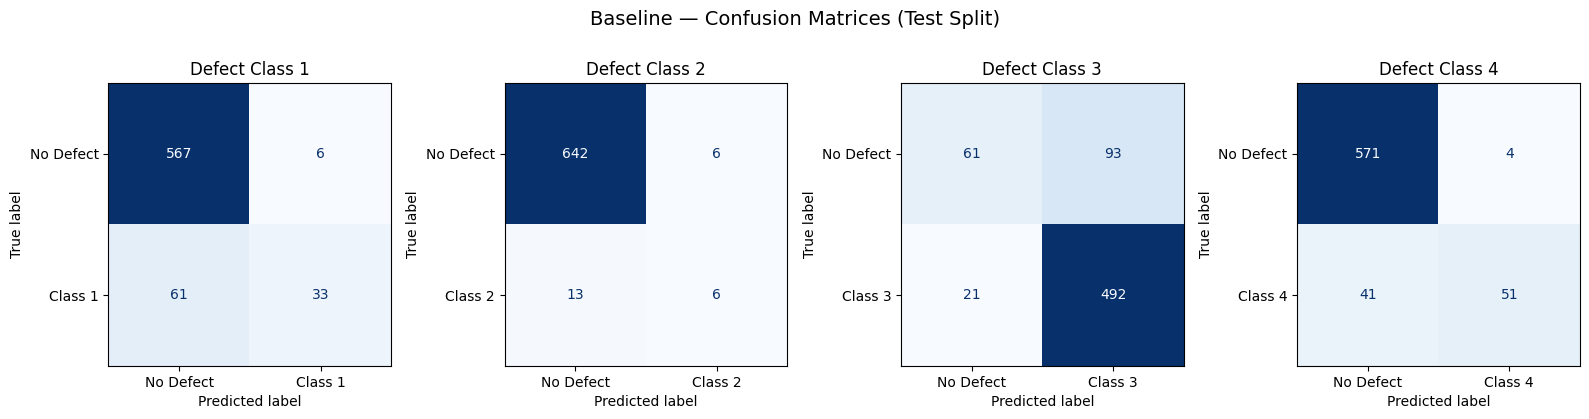

In [9]:
# Per-class binary confusion matrices (failure case analysis)
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(test_labels[:, i], test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Baseline — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

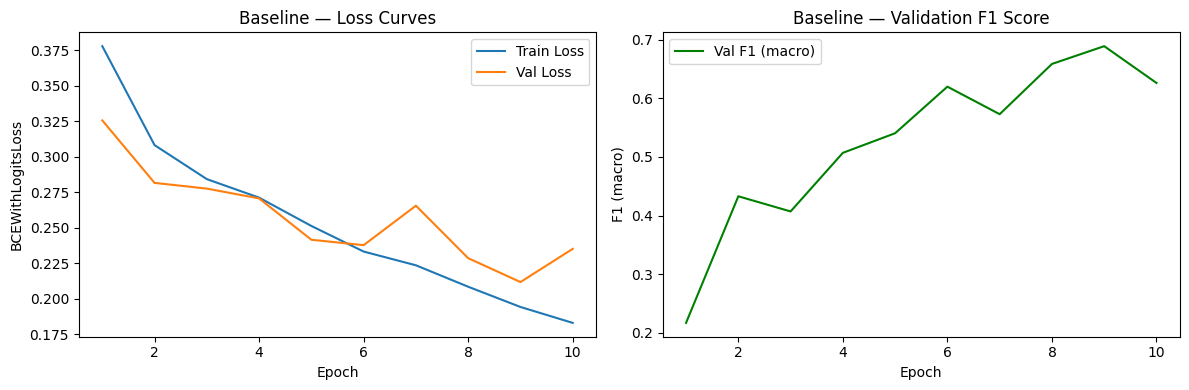

In [10]:
# Baseline training curves
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, baseline_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, baseline_history['val_loss'],   label='Val Loss')
ax1.set_title('Baseline — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(epochs_range, baseline_history['val_f1'], color='green', label='Val F1 (macro)')
ax2.set_title('Baseline — Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

# **Transfer Learning (Frozen Backbone)**
Use a **ResNet-50** backbone pretrained on ImageNet and replace its classification head
for multi-label surface defect detection. **All backbone layers are frozen**, only the new
head is trained. This dramatically reduces training time and leverages features (edges,
textures, shapes) already learned from millions of natural images.

## **3. Network Architecture (Transfer Learning: Frozen Backbone)**
Load a pretrained ResNet-50, freeze the entire backbone, and replace the final
fully-connected layer with a new head for 4-class multi-label output.

In [11]:
# Load pretrained ResNet-50 (modern weights API)
tl_backbone = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)

# Freeze ALL backbone parameters
for param in tl_backbone.parameters():
    param.requires_grad = False

# Replace the classification head
# ResNet-50 fc layer: Linear(in_features=2048, out_features=1000)
# Replace it with the 4-class multi-label head
num_ftrs = tl_backbone.fc.in_features # 2048
tl_backbone.fc = nn.Sequential(
    nn.Linear(num_ftrs, 512),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(512, NUM_CLASSES),
    # NOTE: No Sigmoid — BCEWithLogitsLoss handles it for numerical stability.
)

set_seed(42)
tl_model = tl_backbone.to(device)

# Only optimise the new head parameters (backbone is frozen)
tl_criterion = nn.BCEWithLogitsLoss()
tl_optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, tl_model.parameters()),
    lr=1e-4, # Lower than baseline (1e-3) — head-only training
)

# Verify: count trainable vs total parameters
total_params = sum(p.numel() for p in tl_model.parameters())
trainable_params = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")
print(f"Frozen parameters:    {total_params - trainable_params:,}")
print(f"\nNew classification head:")
print(tl_model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 222MB/s]


Total parameters:     24,559,172
Trainable parameters: 1,051,140 (4.3%)
Frozen parameters:    23,508,032

New classification head:
Sequential(
  (0): Linear(in_features=2048, out_features=512, bias=True)
  (1): ReLU()
  (2): Dropout(p=0.3, inplace=False)
  (3): Linear(in_features=512, out_features=4, bias=True)
)


## **4. Training Loop (Transfer Learning: Frozen Backbone)**
Same training loop structure as the baseline for a fair comparison.
Only the new classification head is updated since backbone gradients are disabled.

In [12]:
tl_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(EPOCHS):
    # Training
    tl_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        tl_optimizer.zero_grad()
        logits = tl_model(images)
        loss   = tl_criterion(logits, labels)
        loss.backward()
        tl_optimizer.step()
        running_loss += loss.item()

    # Validation
    tl_model.eval()
    val_loss  = 0.0
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = tl_model(images)
            val_loss += tl_criterion(logits, labels).item()
            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds  = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg   = val_loss   / len(val_loader)

    tl_history['train_loss'].append(train_loss_avg)
    tl_history['val_loss'].append(val_loss_avg)
    tl_history['val_f1'].append(f1)

    print(
        f"Epoch [{epoch+1:>2}/{EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [ 1/10] | Train Loss: 0.3659 | Val Loss: 0.3144 | Val F1 (macro): 0.2234


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [ 2/10] | Train Loss: 0.3051 | Val Loss: 0.2808 | Val F1 (macro): 0.2938


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

Epoch [ 8/10] | Train Loss: 0.2161 | Val Loss: 0.2105 | Val F1 (macro): 0.5441


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [ 9/10] | Train Loss: 0.2079 | Val Loss: 0.2081 | Val F1 (macro): 0.5727


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


Epoch [10/10] | Train Loss: 0.2086 | Val Loss: 0.2059 | Val F1 (macro): 0.6067


## **5. Test Set Evaluation (Transfer Learning: Frozen Backbone)**
Same evaluation pipeline as the baseline. Compare results directly to quantify
the improvement gained from transfer learning.

In [13]:
tl_model.eval()
tl_test_preds  = []
tl_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = tl_model(images)
        preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        tl_test_preds.append(preds)
        tl_test_labels.append(labels.numpy().astype(int))

tl_test_preds = np.vstack(tl_test_preds)
tl_test_labels = np.vstack(tl_test_labels)

tl_precision = precision_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)
tl_recall = recall_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)
tl_f1_macro = f1_score(tl_test_labels, tl_test_preds, average='macro', zero_division=0)

print("--- Transfer Learning: Final Test Metrics (macro-averaged) ---")
print(f"F1-Score  (macro): {tl_f1_macro:.4f}")
print(f"Precision (macro): {tl_precision:.4f}")
print(f"Recall    (macro): {tl_recall:.4f}")

# Per-class breakdown
print("\n--- Per-Class Metrics ---")
for i, cls in enumerate(CLASS_NAMES):
    p = precision_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    r = recall_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    f = f1_score(tl_test_labels[:, i], tl_test_preds[:, i], zero_division=0)
    print(f"  {cls}: Precision={p:.3f}  Recall={r:.3f}  F1={f:.3f}")

# --- Side-by-side comparison ---
print("\n" + "="*50)
print("COMPARISON: Baseline vs Transfer Learning")
print("="*50)
print(f"{'Metric':<20} {'Baseline':>10} {'TL (ResNet-50)':>15}")
print(f"{'-'*20} {'-'*10} {'-'*15}")
print(f"{'F1 (macro)':<20} {f1_macro:>10.4f} {tl_f1_macro:>15.4f}")
print(f"{'Precision (macro)':<20} {precision:>10.4f} {tl_precision:>15.4f}")
print(f"{'Recall (macro)':<20} {recall:>10.4f} {tl_recall:>15.4f}")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


--- Transfer Learning: Final Test Metrics (macro-averaged) ---
F1-Score  (macro): 0.6579
Precision (macro): 0.9128
Recall    (macro): 0.5854

--- Per-Class Metrics ---
  Class 1: Precision=0.947  Recall=0.574  F1=0.715
  Class 2: Precision=1.000  Recall=0.158  F1=0.273
  Class 3: Precision=0.871  Recall=0.957  F1=0.912
  Class 4: Precision=0.833  Recall=0.652  F1=0.732

COMPARISON: Baseline vs Transfer Learning
Metric                 Baseline  TL (ResNet-50)
-------------------- ---------- ---------------
F1 (macro)               0.6183          0.6579
Precision (macro)        0.7786          0.9128
Recall (macro)           0.5451          0.5854


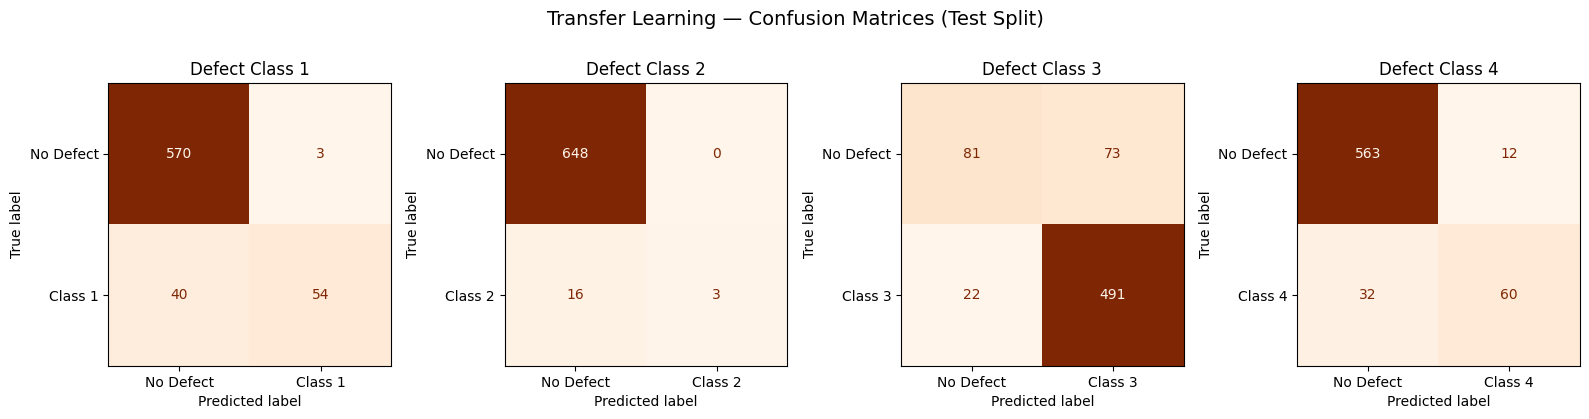

In [14]:
# Per-class binary confusion matrices (Transfer Learning)
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(tl_test_labels[:, i], tl_test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    disp.plot(ax=ax, cmap='Oranges', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Transfer Learning — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

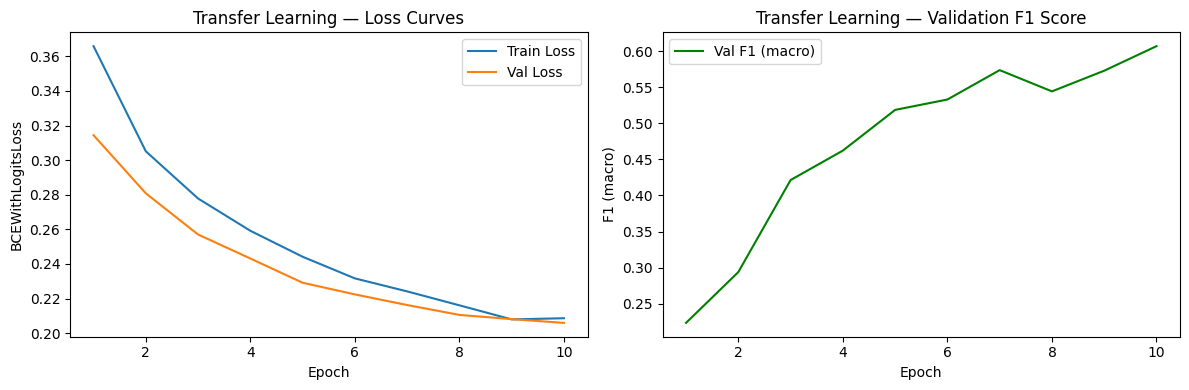

In [15]:
# Transfer Learning training curves
epochs_range = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_range, tl_history['train_loss'], label='Train Loss')
ax1.plot(epochs_range, tl_history['val_loss'],   label='Val Loss')
ax1.set_title('Transfer Learning — Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(epochs_range, tl_history['val_f1'], color='green', label='Val F1 (macro)')
ax2.set_title('Transfer Learning — Validation F1 Score')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

# **Transfer Learning (Partial Fine-tuning)**
Use a **ResNet-50** backbone pretrained on ImageNet and replace its classification head
for multi-label surface defect detection. The last convolutional block (layer4) is unfrozen to allow the deep network to adapt its complex feature representations to the specific defect textures.

### **3-1. Additional Configuration (Transfer Learning: Partial Fine-tuning)**


In [16]:
# 1. Unfreeze the last convolutional block of ResNet-50 (layer4)
for param in tl_model.layer4.parameters():
    param.requires_grad = True

# 2. Verify new trainable parameter count
total_params = sum(p.numel() for p in tl_model.parameters())
trainable_params = sum(p.numel() for p in tl_model.parameters() if p.requires_grad)
print(f"Total parameters:     {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.1f}%)")

# 3. Setup Optimizer with Differential Learning Rates
# Use a very small LR for the pretrained backbone and a slightly larger one for the head
ft_optimizer = optim.Adam([
    {'params': tl_model.layer4.parameters(), 'lr': 1e-5}, # Very low LR for backbone
    {'params': tl_model.fc.parameters(), 'lr': 1e-4}      # Keep previous LR for the head
])

Total parameters:     24,559,172
Trainable parameters: 16,015,876 (65.2%)


## **4. Training Loop (Transfer Learning: Partial Fine-tuning)**

In [17]:
# Fine-tuning Training Loop
FT_EPOCHS = 10 # Usually requires fewer epochs
ft_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(FT_EPOCHS):
    # Training
    tl_model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        ft_optimizer.zero_grad()
        logits = tl_model(images)
        loss = tl_criterion(logits, labels)
        loss.backward()
        ft_optimizer.step()

        running_loss += loss.item()

    # Validation
    tl_model.eval()
    val_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            logits = tl_model(images)
            val_loss += tl_criterion(logits, labels).item()

            preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
            all_preds.append(preds)
            all_labels.append(labels.cpu().numpy().astype(int))

    all_preds = np.vstack(all_preds)
    all_labels = np.vstack(all_labels)

    f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(train_loader)
    val_loss_avg = val_loss / len(val_loader)

    ft_history['train_loss'].append(train_loss_avg)
    ft_history['val_loss'].append(val_loss_avg)
    ft_history['val_f1'].append(f1)

    print(
        f"FT Epoch [{epoch+1:>2}/{FT_EPOCHS}] | "
        f"Train Loss: {train_loss_avg:.4f} | "
        f"Val Loss: {val_loss_avg:.4f} | "
        f"Val F1 (macro): {f1:.4f}"
    )

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


FT Epoch [ 1/10] | Train Loss: 0.1978 | Val Loss: 0.1944 | Val F1 (macro): 0.6279


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


FT Epoch [ 2/10] | Train Loss: 0.1858 | Val Loss: 0.1858 | Val F1 (macro): 0.6309


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


...

FT Epoch [ 8/10] | Train Loss: 0.1367 | Val Loss: 0.1647 | Val F1 (macro): 0.7782


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


FT Epoch [ 9/10] | Train Loss: 0.1302 | Val Loss: 0.1583 | Val F1 (macro): 0.7956


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()


FT Epoch [10/10] | Train Loss: 0.1272 | Val Loss: 0.1558 | Val F1 (macro): 0.7748


## **5. Test Set Evaluation (Transfer Learning: Partial Fine-tuning)**

In [18]:
tl_model.eval()
ft_test_preds = []
ft_test_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        logits = tl_model(images)
        preds = (torch.sigmoid(logits) >= THRESHOLD).cpu().numpy().astype(int)
        ft_test_preds.append(preds)
        ft_test_labels.append(labels.numpy().astype(int))

ft_test_preds = np.vstack(ft_test_preds)
ft_test_labels = np.vstack(ft_test_labels)

ft_f1_macro = f1_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)
print(f"\n--- Fine-Tuning: Final Test F1 (macro): {ft_f1_macro:.4f} ---")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:432: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  self.check_worker_number_rationality()



--- Fine-Tuning: Final Test F1 (macro): 0.8181 ---



FINAL COMPARISON: Baseline vs TL (Head Only) vs Partial Fine-Tuning
Metric                 Baseline       TL (Head)      Fine-Tuned
-------------------- ---------- --------------- ---------------
F1 (macro)               0.6183          0.6579          0.8181
Precision (macro)        0.7786          0.9128          0.8680
Recall (macro)           0.5451          0.5854          0.7770


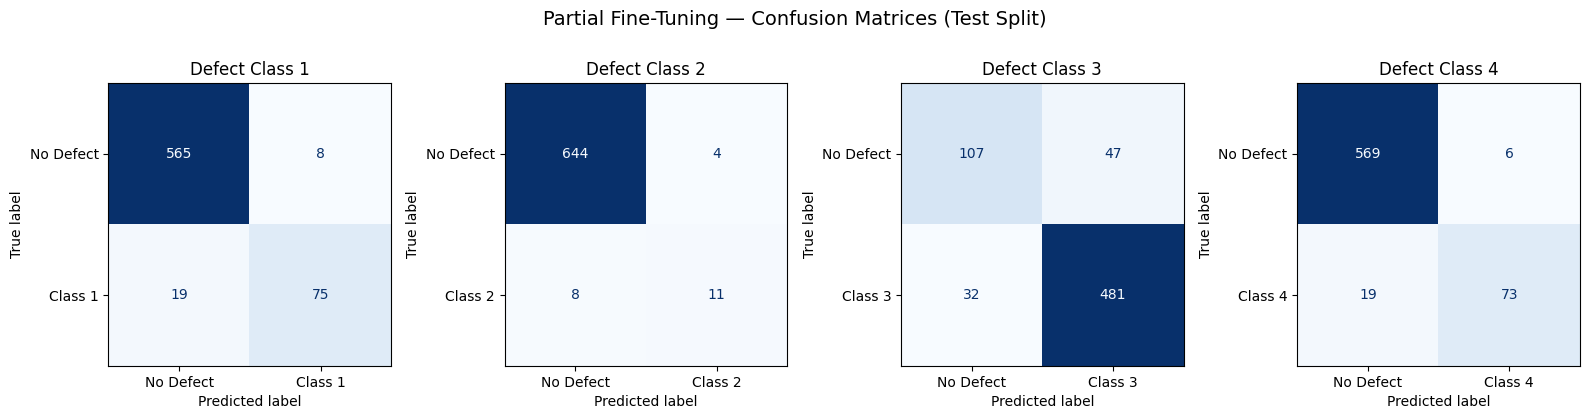

In [19]:
# Calculate Final Fine-Tuned Metrics
ft_precision = precision_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)
ft_recall    = recall_score(ft_test_labels, ft_test_preds, average='macro', zero_division=0)

# 1. Comprehensive Side-by-Side Comparison
print("\n" + "="*65)
print("FINAL COMPARISON: Baseline vs TL (Head Only) vs Partial Fine-Tuning")
print("="*65)
print(f"{'Metric':<20} {'Baseline':>10} {'TL (Head)':>15} {'Fine-Tuned':>15}")
print(f"{'-'*20} {'-'*10} {'-'*15} {'-'*15}")
print(f"{'F1 (macro)':<20} {f1_macro:>10.4f} {tl_f1_macro:>15.4f} {ft_f1_macro:>15.4f}")
print(f"{'Precision (macro)':<20} {precision:>10.4f} {tl_precision:>15.4f} {ft_precision:>15.4f}")
print(f"{'Recall (macro)':<20} {recall:>10.4f} {tl_recall:>15.4f} {ft_recall:>15.4f}")

# 2. Per-class binary confusion matrices (Partial Fine-Tuning)
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    cm = confusion_matrix(ft_test_labels[:, i], ft_test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])
    # Using 'Blues' to visually distinguish from the previous 'Oranges' TL plots
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Partial Fine-Tuning — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

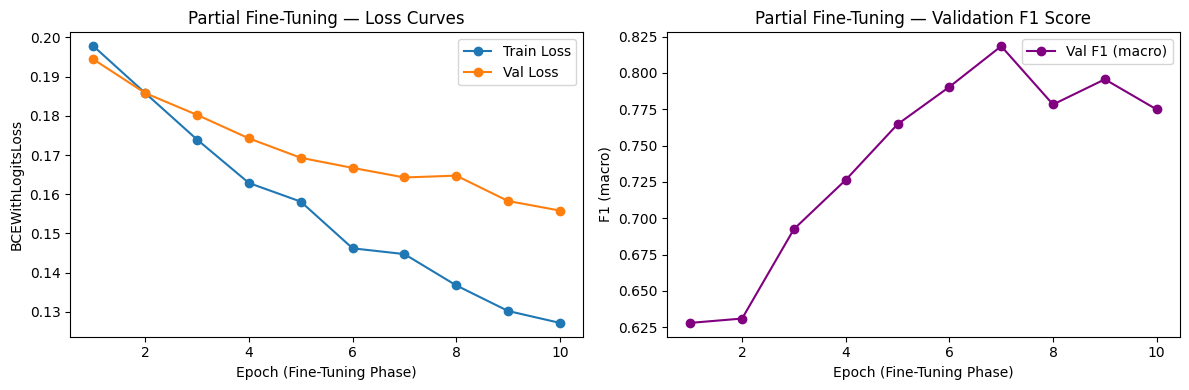

In [20]:
# 3. Fine-Tuning Training Curves
ft_epochs_range = range(1, FT_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(ft_epochs_range, ft_history['train_loss'], label='Train Loss', marker='o')
ax1.plot(ft_epochs_range, ft_history['val_loss'],   label='Val Loss', marker='o')
ax1.set_title('Partial Fine-Tuning — Loss Curves')
ax1.set_xlabel('Epoch (Fine-Tuning Phase)')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(ft_epochs_range, ft_history['val_f1'], color='purple', label='Val F1 (macro)', marker='o')
ax2.set_title('Partial Fine-Tuning — Validation F1 Score')
ax2.set_xlabel('Epoch (Fine-Tuning Phase)')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

# **Advanced Partial Fine-tuning**
Improve the performance of the best performed architecture, partial fine-tuning model, by using:

1. Backbone: EfficientNet-V2-S
2. Feature Aggregation: Concatenating both AdaptiveAvgPool2d and AdaptiveMaxPool2d
3. Augmentation: Add RandomErasing
4. Optimiser: AdamW (weight decay 1e-2)
5. Scheduler: CosineAnnealingLR to control the learning rate across the training cycles
6. Epochs: 30 Epochs

## **2. Model Configuration(Advanced Partial Fine-tuning)**

In [21]:
# 1. Advanced Rectangular Strategy to reserved Horizontal Details
# NOTE: If you hit a CUDA Out of Memory Error, just lower your BATCH_SIZE
rect_train_transform = transforms.Compose([
    transforms.Resize((128, 800)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3), value=0),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

rect_val_transform = transforms.Compose([
    transforms.Resize((128, 800)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create robust Datasets and DataLoaders
heavy_train_dataset = SteelDefectDataset(TRAIN_CSV, IMG_DIR, transform=rect_train_transform)
heavy_train_loader = DataLoader(heavy_train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2, drop_last=True)

heavy_val_dataset = SteelDefectDataset(VAL_CSV, IMG_DIR, transform=rect_val_transform)
heavy_val_loader = DataLoader(heavy_val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

heavy_test_dataset = SteelDefectDataset(TEST_CSV, IMG_DIR, transform=rect_val_transform)
heavy_test_loader = DataLoader(heavy_test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)


## **3. Network Architecture(Advanced Partial Fine-tuning)**

In [22]:
class HeavyFTModel(nn.Module):
    def __init__(self, num_classes=4):
        super().__init__()
        # Load bleeding-edge EfficientNet
        self.backbone = efficientnet_v2_s(weights=EfficientNet_V2_S_Weights.IMAGENET1K_V1)

        # 1. EfficientNet features are mapped sequentially 0 to 7.
        # Freeze early generic blocks, and UNFREEZE blocks 6 and 7 for Fine-Tuning.
        for name, param in self.backbone.features.named_parameters():
            block_idx = int(name.split('.')[0])
            if block_idx >= 6:
                param.requires_grad = True
            else:
                param.requires_grad = False

        # 2. Extract internal features to bypass standard generic limits
        self.features = self.backbone.features

        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)

        # EfficientNet-V2-S output dimension is 1280. Concat max+avg = 2560
        self.head = nn.Sequential(
            nn.Flatten(),
            nn.BatchNorm1d(2560),
            nn.Dropout(0.5),
            nn.Linear(2560, 512),
            nn.ReLU(inplace=True),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x_cat = torch.cat((self.avg_pool(x), self.max_pool(x)), dim=1)
        return self.head(x_cat)

set_seed(42)
advanced_ft_model = HeavyFTModel(num_classes=NUM_CLASSES).to(device)


Downloading: "https://download.pytorch.org/models/efficientnet_v2_s-dd5fe13b.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_v2_s-dd5fe13b.pth


100%|██████████| 82.7M/82.7M [00:00<00:00, 161MB/s]


### **3-1. Optimiser Configuration**

In [23]:
improved_criterion = nn.BCEWithLogitsLoss()

# Map AdamW Optimiser directly to exactly the Unfrozen EfficientNet blocks
unfrozen_backbone_params = []
for name, param in advanced_ft_model.backbone.features.named_parameters():
    block_idx = int(name.split('.')[0])
    if block_idx >= 6:
        unfrozen_backbone_params.append(param)

optimizer_groups = [
    # Profoundly slow mapping applied to avoid breaking the pre-trained EfficientNet weights
    {'params': unfrozen_backbone_params, 'lr': 1e-5},
    # Fast standard mapping for the random Head
    {'params': advanced_ft_model.head.parameters(), 'lr': 1e-3}
]

advanced_ft_optimizer = torch.optim.AdamW(optimizer_groups, weight_decay=1e-2)

ft_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    advanced_ft_optimizer,
    T_max=ADVANCED_EPOCHS * len(heavy_train_loader)
)

## **4. Training Loop (Advanced Partial Fine-tuning)**

In [24]:
val_probs_history = []; val_labels_history = []

print("--- Starting Rectangular Fine-Tuning ---")

aft_history = {'train_loss': [], 'val_loss': [], 'val_f1': []}

for epoch in range(ADVANCED_EPOCHS):
    # Training
    advanced_ft_model.train()
    running_loss = 0.0

    for images, labels in heavy_train_loader:
        images, labels = images.to(device).float(), labels.to(device).float()
        advanced_ft_optimizer.zero_grad()

        logits = advanced_ft_model(images)
        loss = improved_criterion(logits, labels)
        loss.backward()

        advanced_ft_optimizer.step()
        ft_scheduler.step()
        running_loss += loss.item()

    # Validation
    advanced_ft_model.eval()
    val_loss = 0.0 # Initialise val_loss for this epoch
    val_probs_epoch = []; val_labels_epoch = []

    with torch.no_grad():
        for images, labels in heavy_val_loader:
            images, labels = images.to(device).float(), labels.to(device).float()

            # Compute logits and loss for validation
            logits = advanced_ft_model(images)
            batch_loss = improved_criterion(logits, labels)
            val_loss += batch_loss.item()

            probs = torch.sigmoid(logits).cpu().numpy()
            val_probs_epoch.append(probs)
            val_labels_epoch.append(labels.cpu().numpy())

    # Stack the arrays for threshold sweeping (keeps only the latest epoch)
    val_probs_history = np.vstack(val_probs_epoch)
    val_labels_history = np.vstack(val_labels_epoch)

    # Convert probs to binary predictions using a default 0.5 threshold for the epoch history
    val_preds_epoch = (val_probs_history >= 0.5).astype(int)

    # Calculate metrics using the correct variables
    f1 = f1_score(val_labels_history, val_preds_epoch, average='macro', zero_division=0)
    train_loss_avg = running_loss / len(heavy_train_loader)
    val_loss_avg = val_loss / len(heavy_val_loader)

    # Append strictly to aft_history
    aft_history['train_loss'].append(train_loss_avg)
    aft_history['val_loss'].append(val_loss_avg)
    aft_history['val_f1'].append(f1)

    print(f"Epoch [{epoch+1:>2}/{ADVANCED_EPOCHS}] | "
          f"Train Loss: {train_loss_avg:.4f} | "
          f"Val Loss: {val_loss_avg:.4f} | "
          f"Val F1: {f1:.4f} | "
          f"LR [backbone, head]: [{ft_scheduler.get_last_lr()[0]:.6f}, {ft_scheduler.get_last_lr()[1]:.6f}]")

--- Starting Rectangular Fine-Tuning ---
Epoch [ 1/30] | Train Loss: 0.5157 | Val Loss: 0.2614 | Val F1: 0.6241 | LR [backbone, head]: [0.000010, 0.000997]
Epoch [ 2/30] | Train Loss: 0.2797 | Val Loss: 0.1895 | Val F1: 0.7071 | LR [backbone, head]: [0.000010, 0.000989]
Epoch [ 3/30] | Train Loss: 0.2277 | Val Loss: 0.1672 | Val F1: 0.7265 | LR [backbone, head]: [0.000010, 0.000976]
Epoch [ 4/30] | Train Loss: 0.2027 | Val Loss: 0.1492 | Val F1: 0.7748 | LR [backbone, head]: [0.000010, 0.000957]
Epoch [ 5/30] | Train Loss: 0.1884 | Val Loss: 0.1440 | Val F1: 0.7975 | LR [backbone, head]: [0.000009, 0.000933]
Epoch [ 6/30] | Train Loss: 0.1674 | Val Loss: 0.1324 | Val F1: 0.7957 | LR [backbone, head]: [0.000009, 0.000905]
Epoch [ 7/30] | Train Loss: 0.1581 | Val Loss: 0.1377 | Val F1: 0.8184 | LR [backbone, head]: [0.000009, 0.000872]
Epoch [ 8/30] | Train Loss: 0.1550 | Val Loss: 0.1340 | Val F1: 0.7937 | LR [backbone, head]: [0.000008, 0.000835]
Epoch [ 9/30] | Train Loss: 0.1411 | Va

### **4-1. Dynamic Threshold Optimisation**

In [25]:
print("--- Threshold Sweeping on Final Validation Set ---")
best_thresholds = []

for c in range(NUM_CLASSES):
    precisions, recalls, thresholds = precision_recall_curve(val_labels_history[:, c], val_probs_history[:, c])
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-8)
    best_idx = np.argmax(f1_scores)

    best_t = thresholds[best_idx] if best_idx < len(thresholds) else 0.5
    best_thresholds.append(best_t)
    print(f"Class {c+1} Best Optimised Threshold: {best_t:.3f}")

custom_thresholds = np.array(best_thresholds)


--- Threshold Sweeping on Final Validation Set ---
Class 1 Best Optimised Threshold: 0.504
Class 2 Best Optimised Threshold: 0.639
Class 3 Best Optimised Threshold: 0.362
Class 4 Best Optimised Threshold: 0.540


## **5. Test Set Evaluation (Advanced Partial Fine-tuning)**

In [26]:
advanced_ft_model.eval()
test_probs = []; test_labels_list = []

with torch.no_grad():
    for images, labels in heavy_test_loader:
        images, labels = images.to(device).float(), labels.to(device).float()
        probs = torch.sigmoid(advanced_ft_model(images)).cpu().numpy()
        test_probs.append(probs)
        test_labels_list.append(labels.cpu().numpy().astype(int))

test_probs = np.vstack(test_probs)
test_labels_list = np.vstack(test_labels_list)

# Map custom tuned thresholds over the specific Test Predictions
advanced_test_preds = (test_probs >= custom_thresholds).astype(int)

adv_ft_f1 = f1_score(test_labels_list, advanced_test_preds, average='macro', zero_division=0)
adv_ft_prec = precision_score(test_labels_list, advanced_test_preds, average='macro', zero_division=0)
adv_ft_rec = recall_score(test_labels_list, advanced_test_preds, average='macro', zero_division=0)

print(f"--- Advanced Partial FT Final Test Metric ---")
print(f"F1       (macro): {adv_ft_f1:.4f}")
print(f"Precision (macro): {adv_ft_prec:.4f}")
print(f"Recall   (macro): {adv_ft_rec:.4f}")


--- Advanced Partial FT Final Test Metric ---
F1       (macro): 0.8868
Precision (macro): 0.8936
Recall   (macro): 0.8817



FINAL COMPARISON: Baseline vs TL vs Partial Fine-Tuning vs Advanced FT
Metric                 Baseline       TL (Head)      Fine-Tuned     Advanced FT
-------------------- ---------- --------------- --------------- ---------------
F1 (macro)               0.6183          0.6579          0.8181          0.8868
Precision (macro)        0.7786          0.9128          0.8680          0.8936
Recall (macro)           0.5451          0.5854          0.7770          0.8817


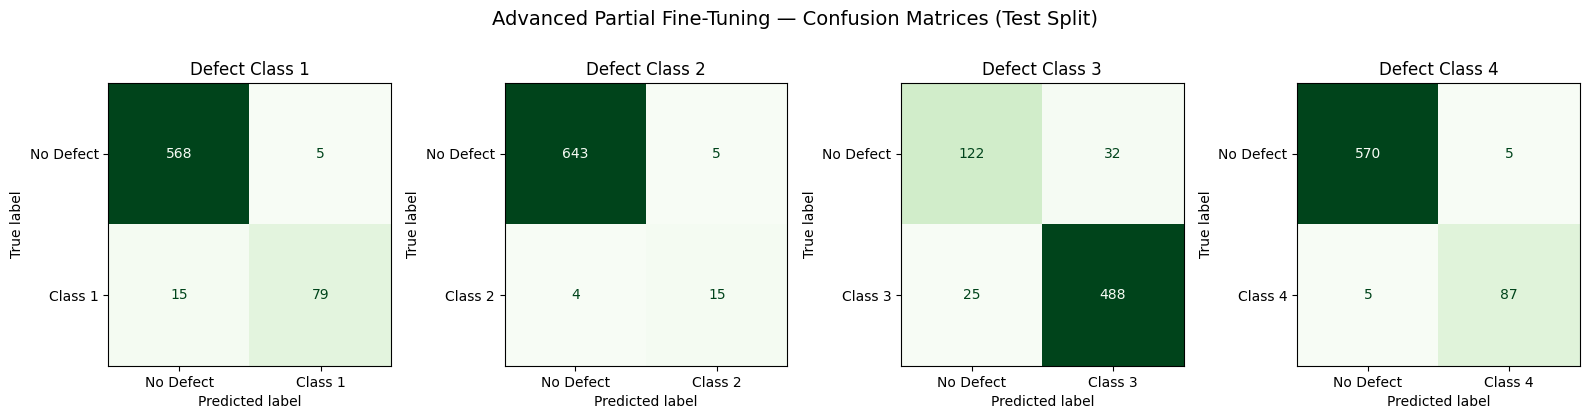

In [27]:
# 1. Comprehensive Side-by-Side Comparison (Including Advanced FT)
print("\n" + "="*85)
print("FINAL COMPARISON: Baseline vs TL vs Partial Fine-Tuning vs Advanced FT")
print("="*85)
print(f"{'Metric':<20} {'Baseline':>10} {'TL (Head)':>15} {'Fine-Tuned':>15} {'Advanced FT':>15}")
print(f"{'-'*20} {'-'*10} {'-'*15} {'-'*15} {'-'*15}")
print(f"{'F1 (macro)':<20} {f1_macro:>10.4f} {tl_f1_macro:>15.4f} {ft_f1_macro:>15.4f} {adv_ft_f1:>15.4f}")
print(f"{'Precision (macro)':<20} {precision:>10.4f} {tl_precision:>15.4f} {ft_precision:>15.4f} {adv_ft_prec:>15.4f}")
print(f"{'Recall (macro)':<20} {recall:>10.4f} {tl_recall:>15.4f} {ft_recall:>15.4f} {adv_ft_rec:>15.4f}")

# 2. Per-class binary confusion matrices (Advanced Partial Fine-Tuning)
fig, axes = plt.subplots(1, NUM_CLASSES, figsize=(16, 4))
for i, ax in enumerate(axes):
    # Using your target test variables
    cm = confusion_matrix(test_labels_list[:, i], advanced_test_preds[:, i])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Defect', f'Class {i+1}'])

    # Using 'Greens' to visually distinguish from 'Blues' (FT) and 'Oranges' (TL)
    disp.plot(ax=ax, cmap='Greens', colorbar=False)
    ax.set_title(f'Defect Class {i+1}', fontsize=12)

plt.suptitle('Advanced Partial Fine-Tuning — Confusion Matrices (Test Split)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

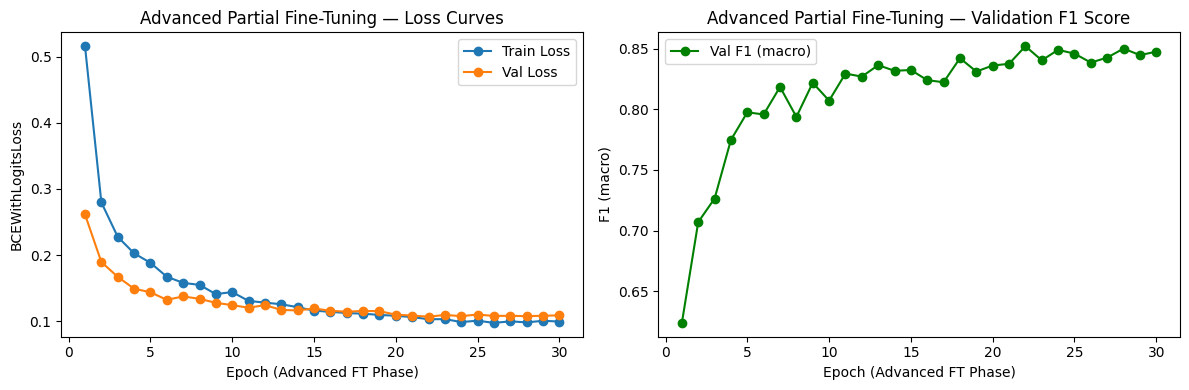

In [28]:
adv_epochs_range = range(1, ADVANCED_EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(adv_epochs_range, aft_history['train_loss'], label='Train Loss', marker='o')
ax1.plot(adv_epochs_range, aft_history['val_loss'],   label='Val Loss', marker='o')
ax1.set_title('Advanced Partial Fine-Tuning — Loss Curves')
ax1.set_xlabel('Epoch (Advanced FT Phase)')
ax1.set_ylabel('BCEWithLogitsLoss')
ax1.legend()

ax2.plot(adv_epochs_range, aft_history['val_f1'], color='green', label='Val F1 (macro)', marker='o')
ax2.set_title('Advanced Partial Fine-Tuning — Validation F1 Score')
ax2.set_xlabel('Epoch (Advanced FT Phase)')
ax2.set_ylabel('F1 (macro)')
ax2.legend()

plt.tight_layout()
plt.show()

# **Final Comparison**

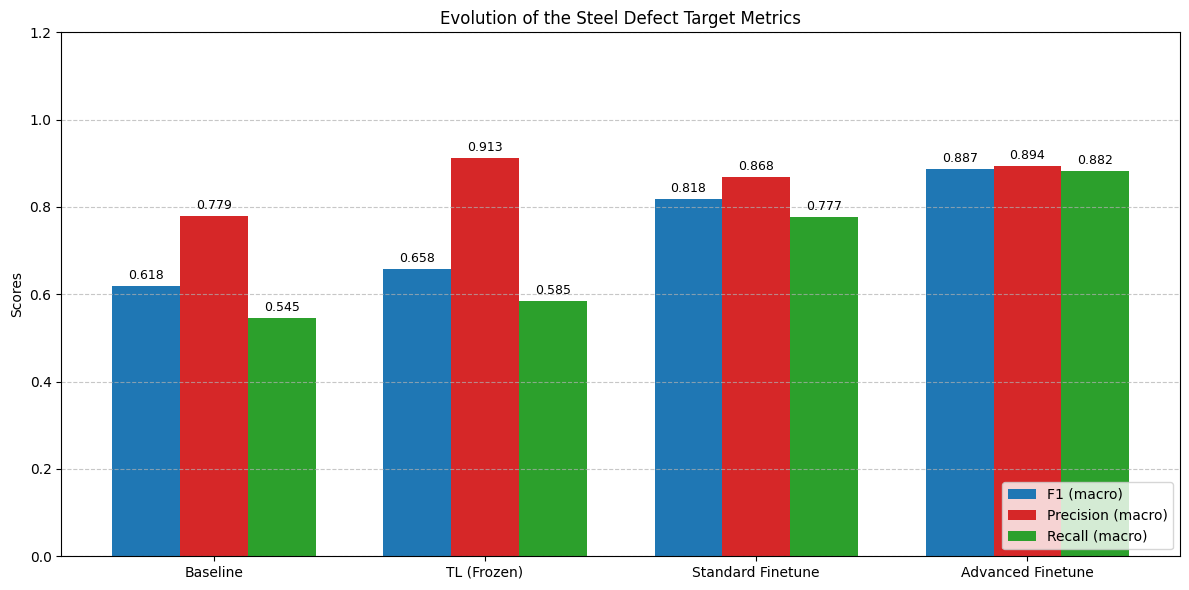

In [29]:
# Plotting the variables defined throughout the notebook across all versions
compare_f1 = [f1_macro, tl_f1_macro, ft_f1_macro, adv_ft_f1]
compare_precision = [precision, tl_precision, ft_precision, adv_ft_prec]
compare_recall = [recall, tl_recall, ft_recall, adv_ft_rec]

models = ['Baseline', 'TL (Frozen)', 'Standard Finetune', 'Advanced Finetune']
x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(12, 6))

rects1 = ax.bar(x - width, compare_f1, width, label='F1 (macro)', color='#1f77b4')
rects2 = ax.bar(x, compare_precision, width, label='Precision (macro)', color='#d62728')
rects3 = ax.bar(x + width, compare_recall, width, label='Recall (macro)', color='#2ca02c')

ax.set_ylabel('Scores')
ax.set_title('Evolution of the Steel Defect Target Metrics')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend(loc='lower right')

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)
autolabel(rects3)

plt.ylim(0, 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
